🔍 최고 정밀도: 120 epoch
🔍 최고 재현율: 110 epoch
🔍 최고 mAP@50: 119 epoch
🔍 최고 mAP@50-95: 119 epoch


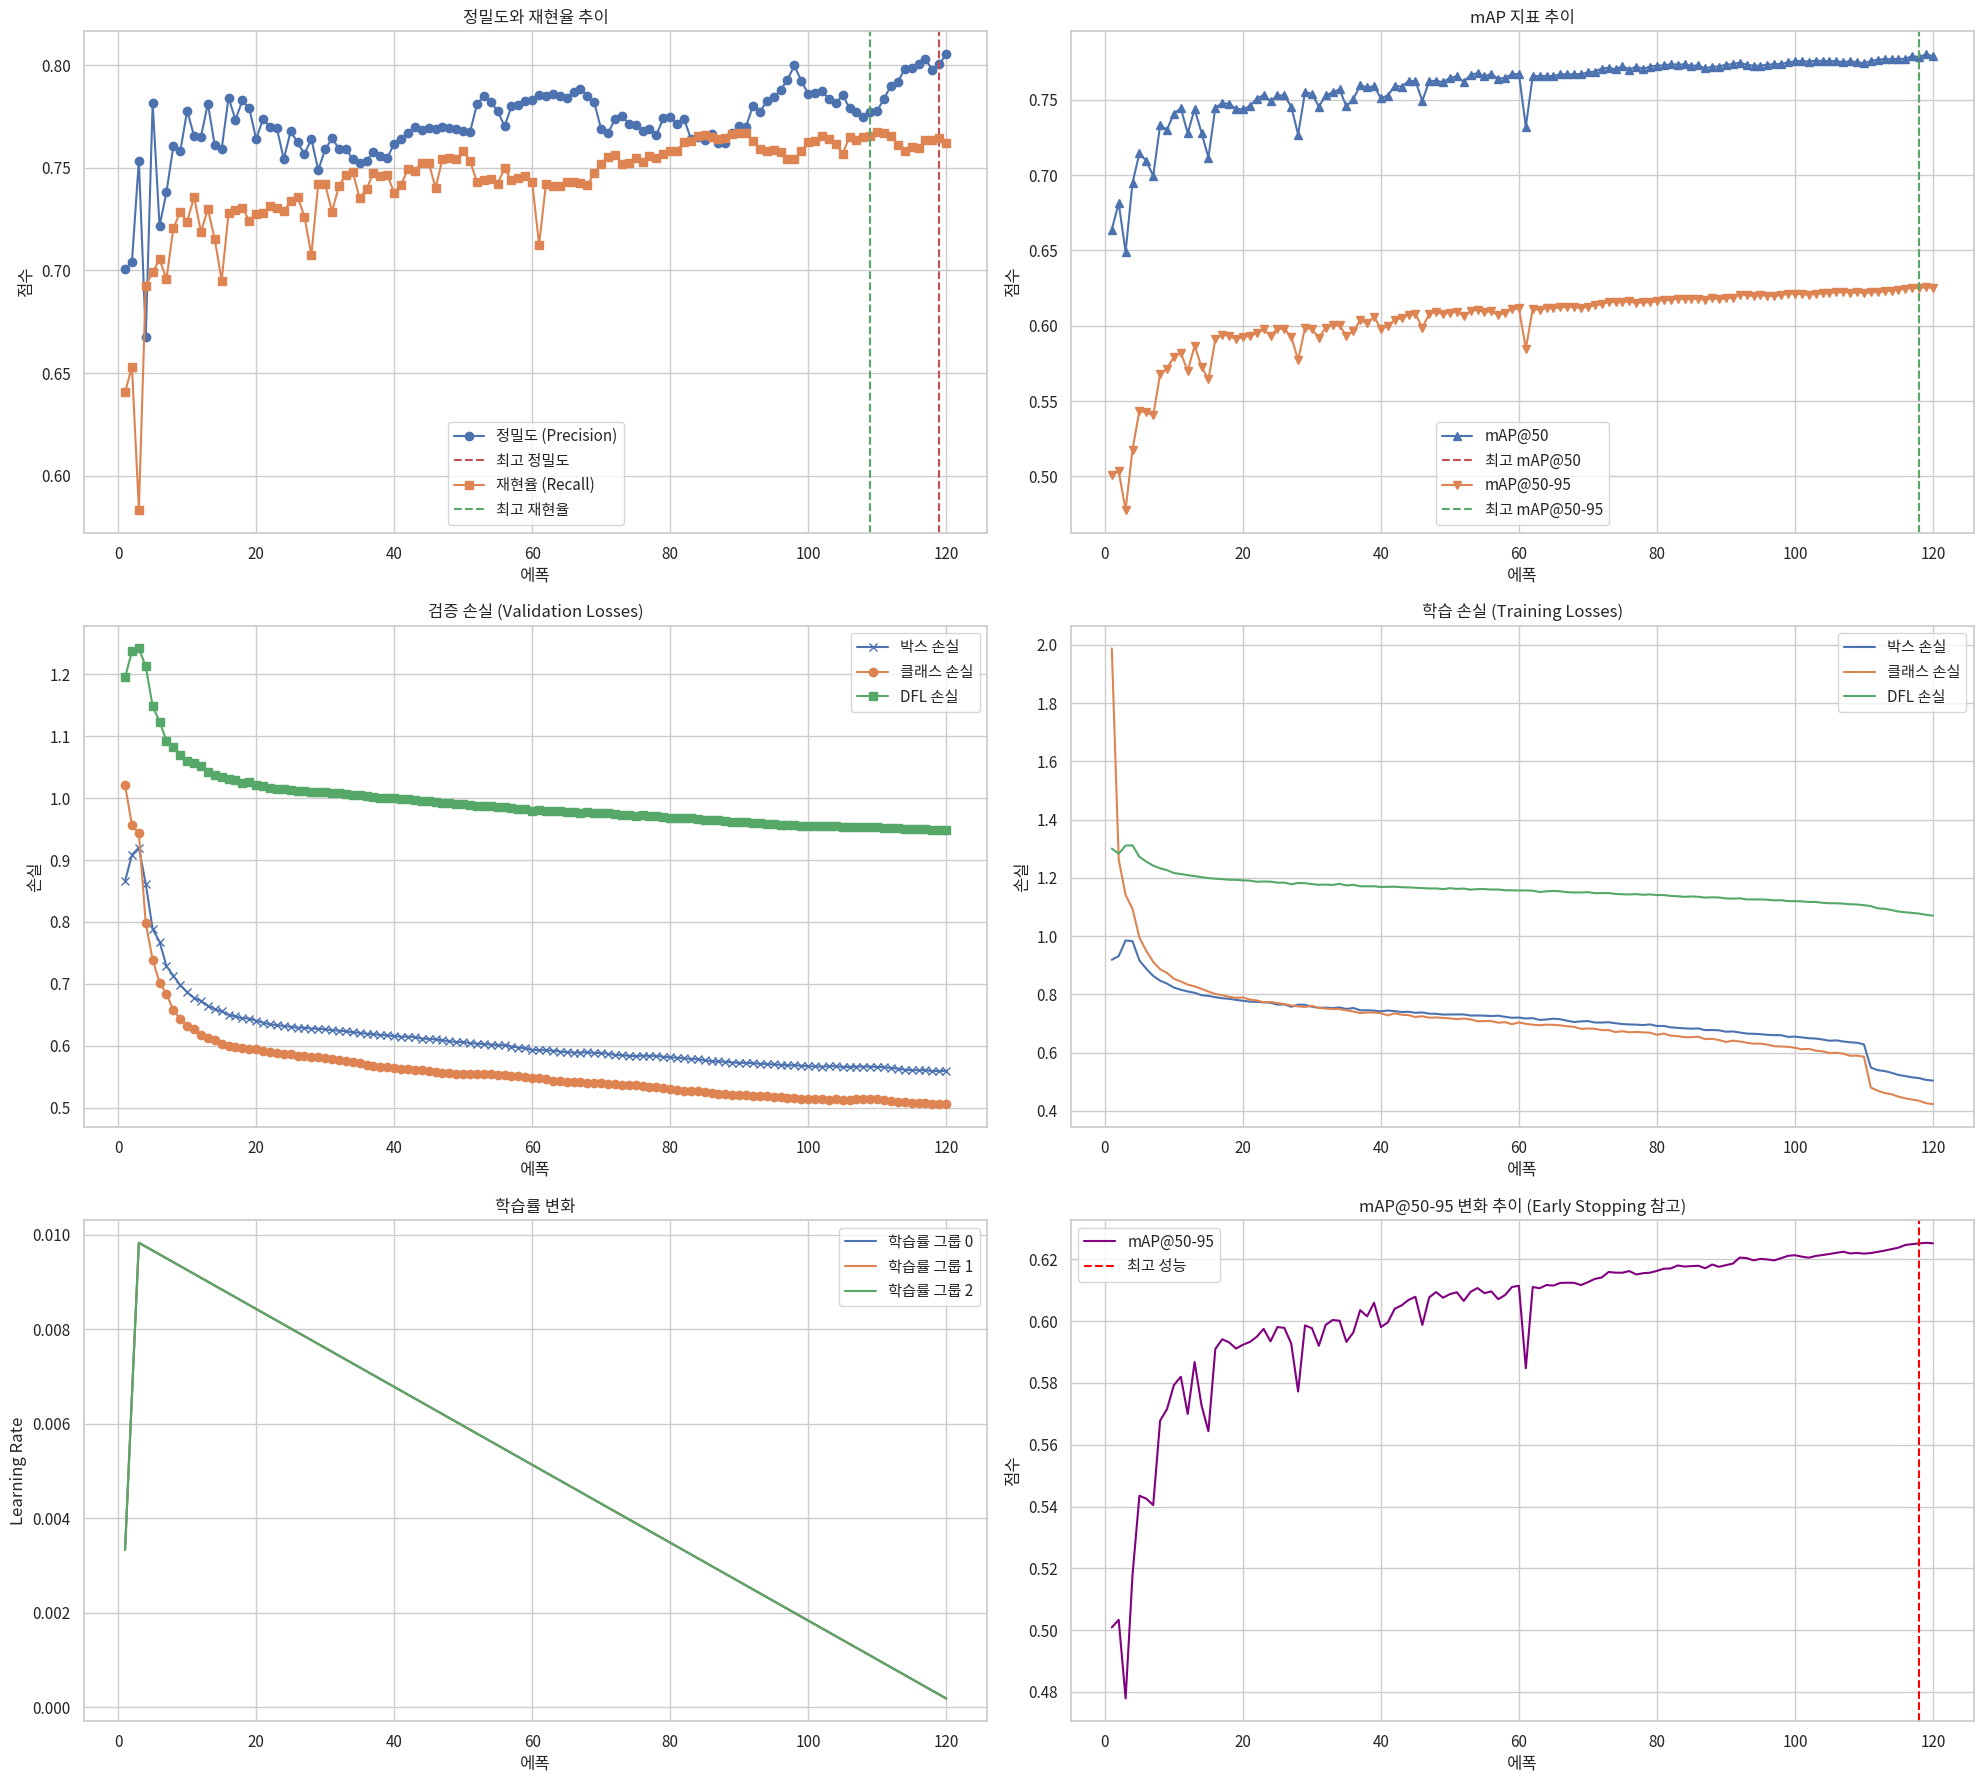

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import platform
import matplotlib.font_manager as fm

# ------------------------------------------------
# ✅ 한글 폰트 설정 (OS에 따라 다르게)
# ------------------------------------------------
if platform.system() == 'Windows':
    # Noto Sans KR 경로 검색
    font_paths = [f for f in fm.findSystemFonts(fontpaths=None, fontext='ttf') if 'NotoSansKR' in f]
    if font_paths:
        font_path = font_paths[0]
        font_prop = fm.FontProperties(fname=font_path)
        plt.rc('font', family=font_prop.get_name())
    else:
        print("⚠ NotoSansKR 폰트를 찾을 수 없습니다. 기본 폰트로 대체합니다.")
        plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')  # macOS
else:
    plt.rc('font', family='NanumGothic')  # Linux

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지


# ------------------------------------------------
# 데이터 로드
# ------------------------------------------------
df = pd.read_csv("./results.csv")

# 최고 성능 에폭 찾기
best_epoch_precision = df['metrics/precision(B)'].idxmax()
best_epoch_recall = df['metrics/recall(B)'].idxmax()
best_epoch_map50 = df['metrics/mAP50(B)'].idxmax()
best_epoch_map95 = df['metrics/mAP50-95(B)'].idxmax()

# 결과 출력
print(f"🔍 최고 정밀도: {df.loc[best_epoch_precision, 'epoch']} epoch")
print(f"🔍 최고 재현율: {df.loc[best_epoch_recall, 'epoch']} epoch")
print(f"🔍 최고 mAP@50: {df.loc[best_epoch_map50, 'epoch']} epoch")
print(f"🔍 최고 mAP@50-95: {df.loc[best_epoch_map95, 'epoch']} epoch")

# ------------------------------------------------
# 시각화
# ------------------------------------------------
plt.figure(figsize=(20, 18))

# 1. Precision & Recall
plt.subplot(3, 2, 1)
plt.plot(df['epoch'], df['metrics/precision(B)'], label='정밀도 (Precision)', marker='o')
plt.axvline(x=best_epoch_precision, color='r', linestyle='--', label='최고 정밀도')
plt.plot(df['epoch'], df['metrics/recall(B)'], label='재현율 (Recall)', marker='s')
plt.axvline(x=best_epoch_recall, color='g', linestyle='--', label='최고 재현율')
plt.title("정밀도와 재현율 추이")
plt.xlabel("에폭")
plt.ylabel("점수")
plt.legend()

# 2. mAP50 / mAP50-95
plt.subplot(3, 2, 2)
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', marker='^')
plt.axvline(x=best_epoch_map50, color='r', linestyle='--', label='최고 mAP@50')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', marker='v')
plt.axvline(x=best_epoch_map95, color='g', linestyle='--', label='최고 mAP@50-95')
plt.title("mAP 지표 추이")
plt.xlabel("에폭")
plt.ylabel("점수")
plt.legend()

# 3. 검증 손실
plt.subplot(3, 2, 3)
plt.plot(df['epoch'], df['val/box_loss'], label='박스 손실', marker='x')
plt.plot(df['epoch'], df['val/cls_loss'], label='클래스 손실', marker='o')
plt.plot(df['epoch'], df['val/dfl_loss'], label='DFL 손실', marker='s')
plt.title("검증 손실 (Validation Losses)")
plt.xlabel("에폭")
plt.ylabel("손실")
plt.legend()

# 4. 학습 손실
plt.subplot(3, 2, 4)
plt.plot(df['epoch'], df['train/box_loss'], label='박스 손실')
plt.plot(df['epoch'], df['train/cls_loss'], label='클래스 손실')
plt.plot(df['epoch'], df['train/dfl_loss'], label='DFL 손실')
plt.title("학습 손실 (Training Losses)")
plt.xlabel("에폭")
plt.ylabel("손실")
plt.legend()

# 5. 러닝레이트 변화
plt.subplot(3, 2, 5)
plt.plot(df['epoch'], df['lr/pg0'], label='학습률 그룹 0')
plt.plot(df['epoch'], df['lr/pg1'], label='학습률 그룹 1')
plt.plot(df['epoch'], df['lr/pg2'], label='학습률 그룹 2')
plt.title("학습률 변화")
plt.xlabel("에폭")
plt.ylabel("Learning Rate")
plt.legend()

# 6. mAP@50-95 변화 추이 (EarlyStopping 참고)
plt.subplot(3, 2, 6)
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='purple')
plt.axvline(x=best_epoch_map95, color='red', linestyle='--', label='최고 성능')
plt.title("mAP@50-95 변화 추이 (Early Stopping 참고)")
plt.xlabel("에폭")
plt.ylabel("점수")
plt.legend()

# 전체 레이아웃 정리
plt.tight_layout()
plt.show()
